In [1]:
from google.colab import drive
import os

# Монтируем Google Диск
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Задаём папку для логов на Диске (можно изменить название)
base_log_dir = '/content/drive/MyDrive/ЦУ Курсы/Метопты'
os.makedirs(base_log_dir, exist_ok=True)  # создаём, если не существует

In [3]:
optuna_dir = '/content/drive/MyDrive/ЦУ Курсы/Метопты/Optuna_logs'
bayes_dir = '/content/drive/MyDrive/ЦУ Курсы/Метопты/Bayes_logs'
random_dir = '/content/drive/MyDrive/ЦУ Курсы/Метопты/Random_logs'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [5]:
#1. Проверяем пути к папкам
base_path = "/content/drive/MyDrive/ЦУ Курсы/Метопты"
bayes_dir = os.path.join(base_path, "Bayes_logs")
optuna_dir = os.path.join(base_path, "Optuna_logs")
random_dir = os.path.join(base_path, "Random_logs")

print("Проверка существования папок:")
print(f"  Bayes:  {os.path.exists(bayes_dir)}")
print(f"  Optuna: {os.path.exists(optuna_dir)}")
print(f"  Random: {os.path.exists(random_dir)}")

Проверка существования папок:
  Bayes:  True
  Optuna: True
  Random: True


### Загрузка логов

In [6]:
def load_all_logs(base_dir, prefix):
    """
    Загружает все CSV-файлы из папки с заданным префиксом.
    Возвращает словарь {(model, dataset): DataFrame}.
    """
    results = {}
    if not os.path.exists(base_dir):
        print(f"  Папка не найдена: {base_dir}")
        return results

    for filename in os.listdir(base_dir):
        if not filename.endswith('.csv'):
            continue

        # Убираем префикс и расширение
        name = filename.replace(prefix + '_', '').replace('.csv', '')
        parts = name.split('_', 1)

        if len(parts) < 2:
            # Если не получается разбить (например, RandomForest — одно слово)
            # пробуем найти известные модели и датасеты
            model_found = None
            dataset_found = None
            known_models = ['LogisticRegression', 'RandomForest', 'LightGBM',
                           'CatBoost', 'Ridge', 'Lasso', 'ElasticNet']
            known_datasets = ['Adult', 'Bank', 'California', 'Superconductivity', 'Spam']

            for m in known_models:
                if name.startswith(m):
                    model_found = m
                    dataset_found = name[len(m):].lstrip('_')
                    break
                if m in name:
                    model_found = m
                    dataset_found = name.replace(m, '').strip('_')
                    break

            if model_found and dataset_found:
                parts = [model_found, dataset_found]
            else:
                print(f"  ⚠ Не удалось разобрать имя файла: {filename}")
                continue

        model = parts[0]
        dataset = parts[1]
        filepath = os.path.join(base_dir, filename)

        try:
            df = pd.read_csv(filepath)
            # Приводим best_params к строке, если это dict
            if 'best_params' in df.columns:
                df['best_params'] = df['best_params'].astype(str)
            results[(model, dataset)] = df
        except Exception as e:
            print(f"  Ошибка при чтении {filename}: {e}")

    print(f" Загружено {len(results)} файлов из {os.path.basename(base_dir)}")
    return results

In [7]:
bayes_logs = load_all_logs(bayes_dir, "bayes")
optuna_logs = load_all_logs(optuna_dir, "optuna")
random_logs = load_all_logs(random_dir, "random")

 Загружено 19 файлов из Bayes_logs
 Загружено 19 файлов из Optuna_logs
 Загружено 19 файлов из Random_logs


### Собираем финальные результаты

In [8]:
def get_final_score(logs_dict, method_name):
    """
    Извлекает итоговые значения метрики для каждого датасета-модели.
    Берёт последнее (финальное) значение best_score.
    """
    records = []
    for (model, dataset), df in logs_dict.items():
        final_row = df.iloc[-1]
        records.append({
            'model': model,
            'dataset': dataset,
            'method': method_name,
            'best_score': final_row['best_score'],
            'task': final_row.get('task', '?'),
            'metric': final_row.get('metric', '?')
        })
    return pd.DataFrame(records)

# Собираем итоговые результаты
df_bayes_final = get_final_score(bayes_logs, 'Bayesian (GP)')
df_optuna_final = get_final_score(optuna_logs, 'TPE (Optuna)')
df_random_final = get_final_score(random_logs, 'Random Search')

df_all_final = pd.concat([df_bayes_final, df_optuna_final, df_random_final], ignore_index=True)

print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*60)
print(df_all_final.to_string(index=False))


ИТОГОВЫЕ РЕЗУЛЬТАТЫ
             model                dataset        method    best_score           task  metric
LogisticRegression             Adult_logs Bayesian (GP)  9.056682e-01 classification ROC-AUC
LogisticRegression              Bank_logs Bayesian (GP)  7.713309e-01 classification ROC-AUC
LogisticRegression              Spam_logs Bayesian (GP)  9.723499e-01 classification ROC-AUC
             Ridge        California_logs Bayesian (GP) -4.769079e+09     regression     MSE
             Ridge Superconductivity_logs Bayesian (GP) -3.114854e+02     regression     MSE
             Lasso        California_logs Bayesian (GP) -4.769002e+09     regression     MSE
             Lasso Superconductivity_logs Bayesian (GP) -3.119389e+02     regression     MSE
        ElasticNet        California_logs Bayesian (GP) -4.769222e+09     regression     MSE
        ElasticNet Superconductivity_logs Bayesian (GP) -3.127718e+02     regression     MSE
      RandomForest             Adult_logs Bayesia

In [9]:
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА")
print("="*60)

# Разделяем классификацию и регрессию
for task_type in ['classification', 'regression']:
    df_task = df_all_final[df_all_final['task'] == task_type]
    if len(df_task) == 0:
        continue

    pivot = df_task.pivot_table(
        values='best_score',
        index=['model', 'dataset'],
        columns='method',
        aggfunc='first'
    ).round(4)

    print(f"\n--- {task_type.upper()} ---")
    print(pivot.to_string())

    # Сохраняем в CSV
    pivot.to_csv(os.path.join(base_path, f'summary_{task_type}.csv'))
    print(f"Сохранено в summary_{task_type}.csv")


СВОДНАЯ ТАБЛИЦА

--- CLASSIFICATION ---
method                         Bayesian (GP)  Random Search  TPE (Optuna)
model              dataset                                               
CatBoost           Adult_logs         0.9290         0.9286        0.9292
                   Bank_logs          0.8070         0.8065        0.8071
                   Spam_logs          0.9887         0.9880        0.9883
LogisticRegression Adult_logs         0.9057         0.9061        0.9063
                   Bank_logs          0.7713         0.7712        0.7712
                   Spam_logs          0.9723         0.9723        0.9724
RandomForest       Adult_logs         0.9184         0.9184        0.9185
                   Bank_logs          0.7963         0.7965        0.7966
                   Spam_logs          0.9852         0.9838        0.9842
Сохранено в summary_classification.csv

--- REGRESSION ---
method                               Bayesian (GP)  Random Search  TPE (Optuna)
model 

### Смотрим на графики


ПОСТРОЕНИЕ ГРАФИКОВ
Всего пар модель-датасет: 19
Общий график сохранен: /content/drive/MyDrive/ЦУ Курсы/Метопты/dynamics_all_pairs.png


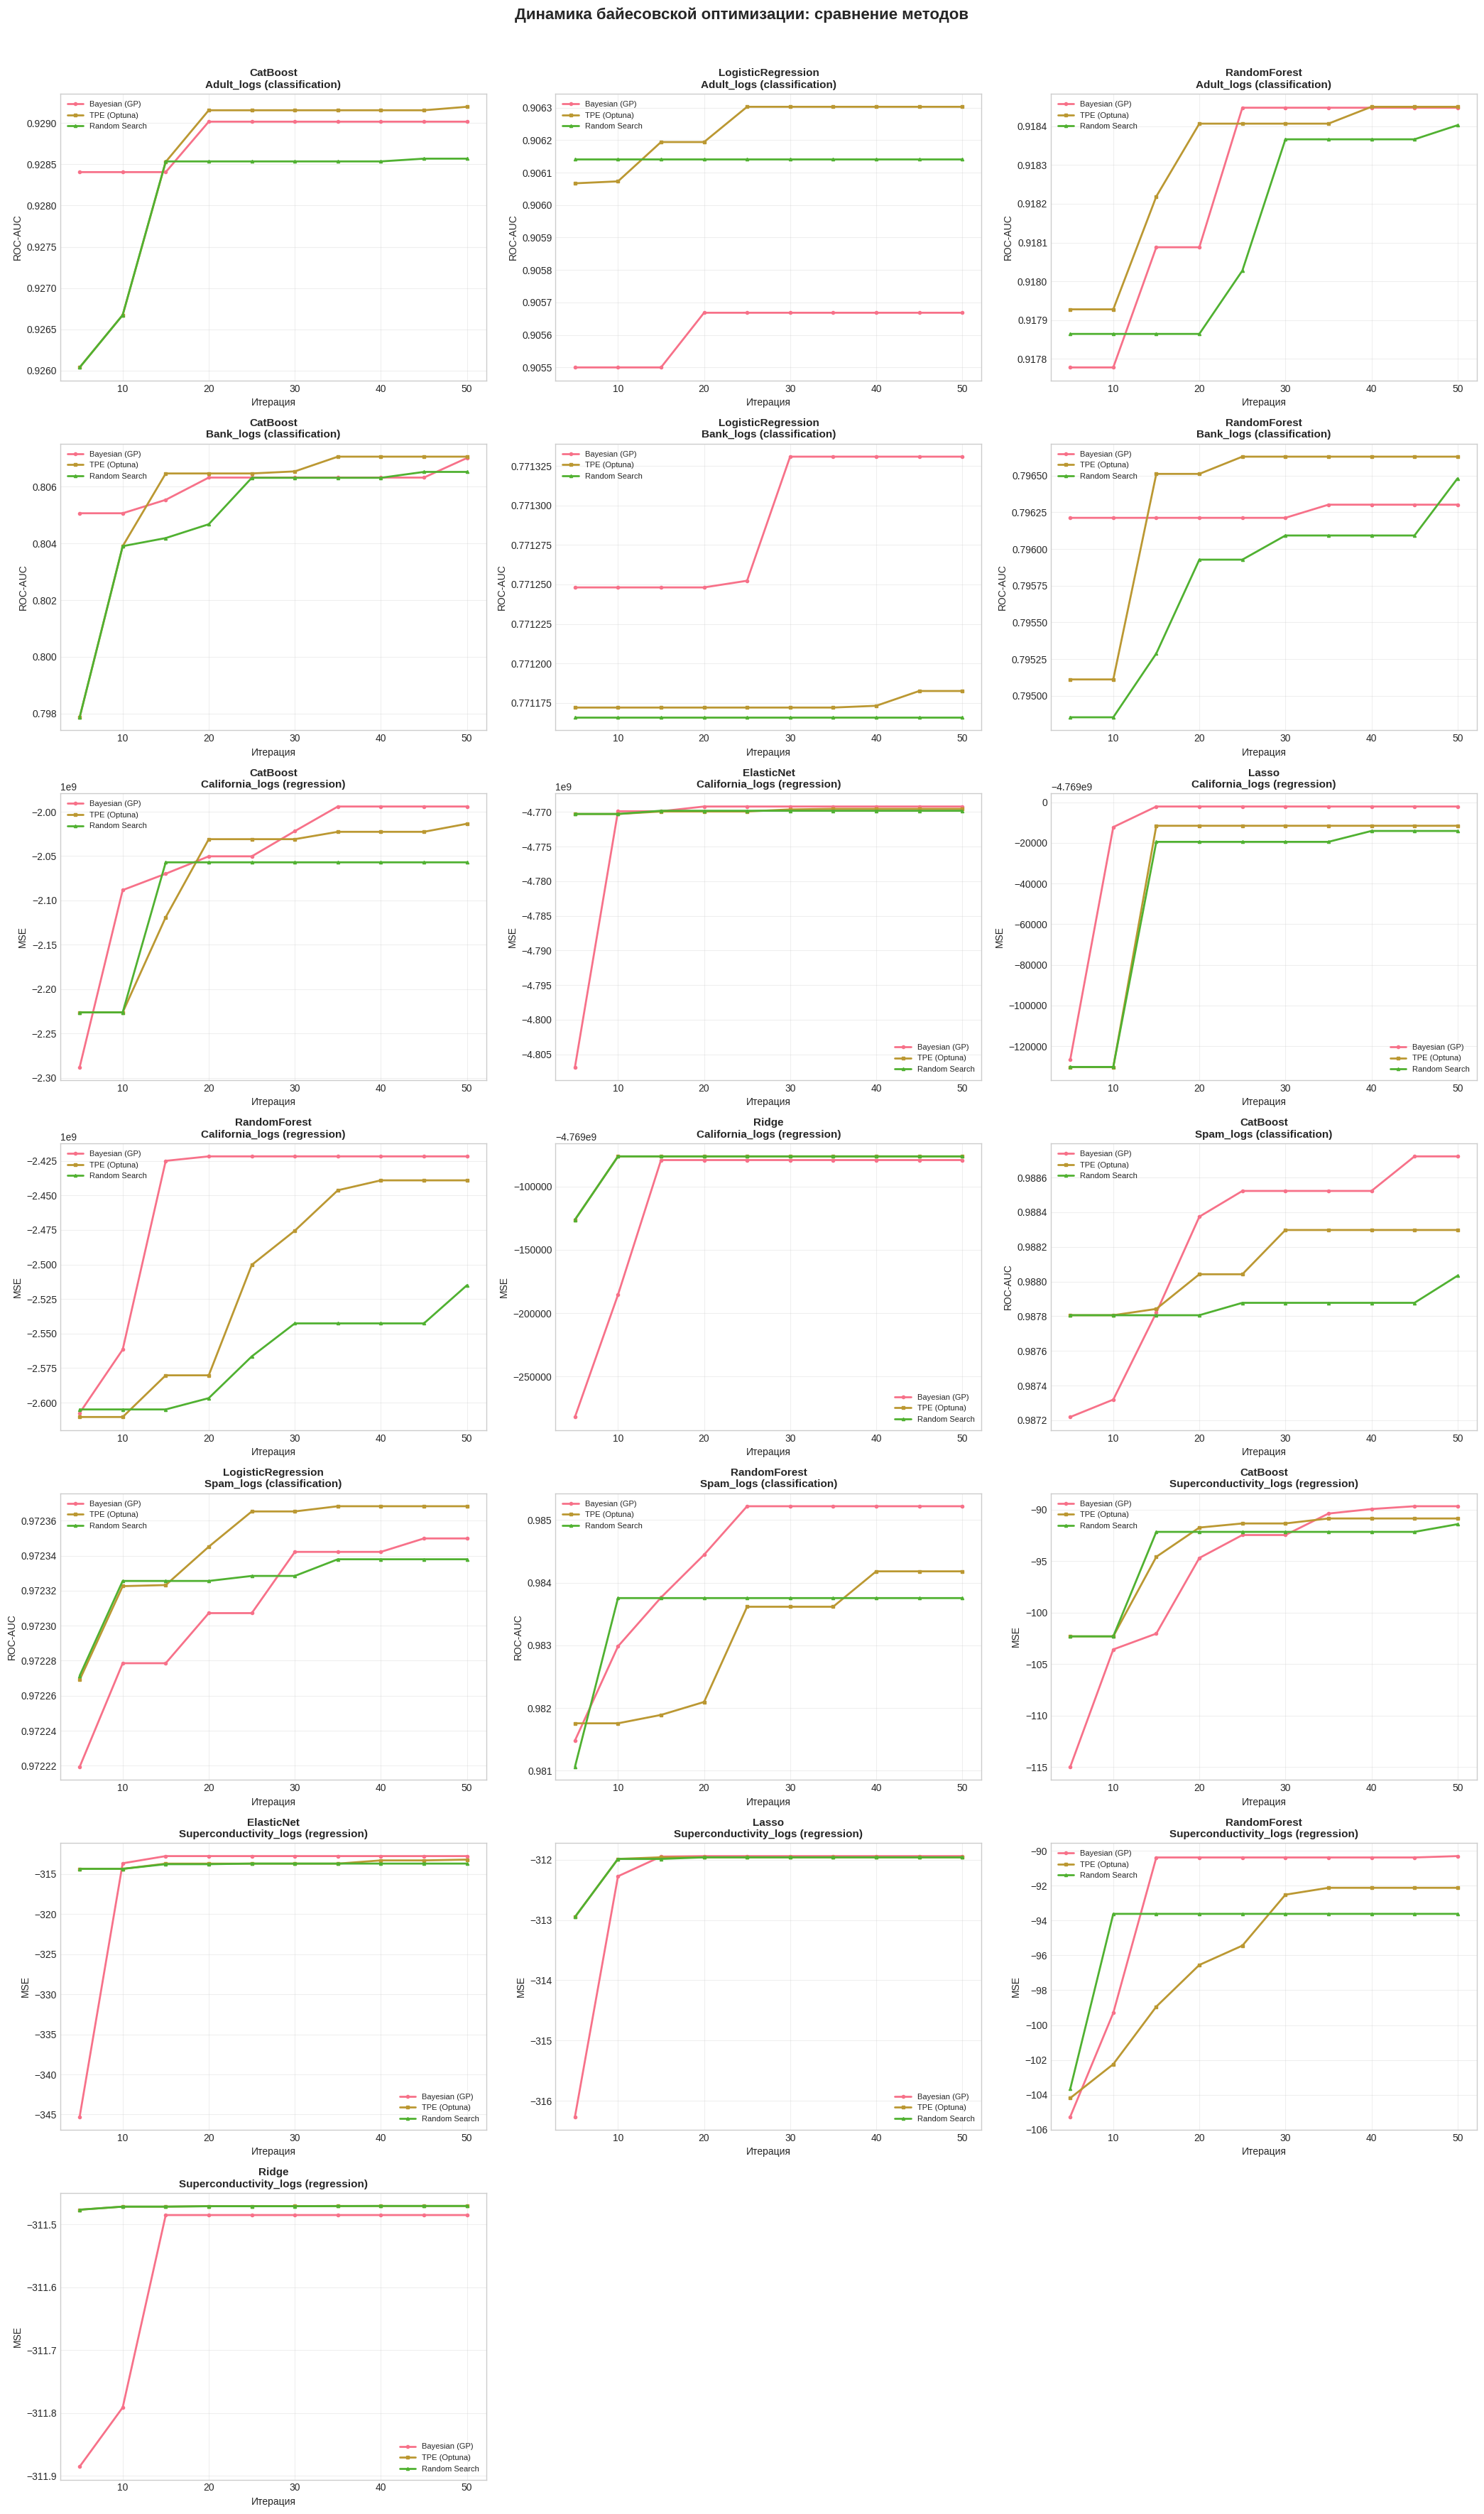

In [10]:
# ============================================================
# 6. ГРАФИКИ ДИНАМИКИ ПО ИТЕРАЦИЯМ
# ============================================================

print("\n" + "="*60)
print("ПОСТРОЕНИЕ ГРАФИКОВ")
print("="*60)

# Собираем все уникальные пары модель-датасет
all_pairs = set()
for logs in [bayes_logs, optuna_logs, random_logs]:
    all_pairs.update(logs.keys())

# Сортируем пары для удобства
all_pairs = sorted(all_pairs, key=lambda x: (x[1], x[0]))  # по датасету, потом по модели

print(f"Всего пар модель-датасет: {len(all_pairs)}")

# Определяем количество строк и столбцов для subplots
n_pairs = len(all_pairs)
n_cols = 3  # по 3 графика в строке
n_rows = (n_pairs + n_cols - 1) // n_cols

# Создаём фигуру
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
axes = axes.flatten() if n_pairs > 1 else [axes]

# Для отслеживания пар, по которым есть данные во всех трёх методах
pairs_with_data = []

for idx, (model, dataset) in enumerate(all_pairs):
    ax = axes[idx]

    # Достаём данные из всех трёх методов
    df_b = bayes_logs.get((model, dataset))
    df_o = optuna_logs.get((model, dataset))
    df_r = random_logs.get((model, dataset))

    has_data = False

    if df_b is not None:
        ax.plot(df_b['iteration'], df_b['best_score'],
                marker='o', markersize=3, linewidth=2, label='Bayesian (GP)')
        has_data = True

    if df_o is not None:
        ax.plot(df_o['iteration'], df_o['best_score'],
                marker='s', markersize=3, linewidth=2, label='TPE (Optuna)')
        has_data = True

    if df_r is not None:
        ax.plot(df_r['iteration'], df_r['best_score'],
                marker='^', markersize=3, linewidth=2, label='Random Search')
        has_data = True

    if has_data:
        pairs_with_data.append((model, dataset))
        # Определяем задачу по имеющимся данным
        task = None
        for df in [df_b, df_o, df_r]:
            if df is not None and 'task' in df.columns:
                task = df['task'].iloc[0] if len(df) > 0 else None
                break

        metric = 'ROC-AUC' if task == 'classification' else 'MSE'
        ax.set_title(f'{model}\n{dataset} ({task})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Итерация')
        ax.set_ylabel(metric)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

# Скрываем пустые subplot'ы
for idx in range(n_pairs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Динамика байесовской оптимизации: сравнение методов',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

# Сохраняем общий график
output_plot = os.path.join(base_path, 'dynamics_all_pairs.png')
plt.savefig(output_plot, dpi=150, bbox_inches='tight')
print(f"Общий график сохранен: {output_plot}")
plt.show()

### Прирост относительно рандома

In [11]:
print("\n" + "="*60)
print("СРАВНЕНИЕ: ПРИРОСТ НАД RANDOM SEARCH")
print("="*60)

# Создаём сводную таблицу с приростом
comparison_records = []

for (model, dataset) in pairs_with_data:
    score_b = None
    score_o = None
    score_r = None

    df_b = bayes_logs.get((model, dataset))
    df_o = optuna_logs.get((model, dataset))
    df_r = random_logs.get((model, dataset))

    if df_b is not None:
        score_b = df_b['best_score'].iloc[-1]
    if df_o is not None:
        score_o = df_o['best_score'].iloc[-1]
    if df_r is not None:
        score_r = df_r['best_score'].iloc[-1]

    # Определяем задачу
    task = None
    for df in [df_b, df_o, df_r]:
        if df is not None and 'task' in df.columns:
            task = df['task'].iloc[0] if len(df) > 0 else None
            break

    # Для MSE: случайный поиск — базовая линия
    if task == 'regression':
        # Для MSE меньше = лучше, но в данных может быть neg_MSE
        # Проверяем знак
        if score_r is not None and score_r > 0:
            # Это MSE, меньше = лучше
            improvement_b = (score_r - score_b) / score_r * 100 if (score_b is not None and score_r != 0) else None
            improvement_o = (score_r - score_o) / score_r * 100 if (score_o is not None and score_r != 0) else None
        else:
            # neg_MSE, больше = лучше
            improvement_b = (score_b - score_r) / abs(score_r) * 100 if (score_b is not None and score_r is not None and score_r != 0) else None
            improvement_o = (score_o - score_r) / abs(score_r) * 100 if (score_o is not None and score_r is not None and score_r != 0) else None
    else:
        # Классификация: больше = лучше
        improvement_b = (score_b - score_r) / score_r * 100 if (score_b is not None and score_r is not None and score_r != 0) else None
        improvement_o = (score_o - score_r) / score_r * 100 if (score_o is not None and score_r is not None and score_r != 0) else None

    # Форматируем значения для удобного отображения
    def fmt_score(score, task_type):
        """Форматирует score в читаемый вид."""
        if score is None:
            return '-'
        if task_type == 'regression':
            # Для регрессии большие числа форматируем с запятыми
            if abs(score) >= 1e6:
                return f"{score:,.2f}"
            elif abs(score) >= 1e3:
                return f"{score:,.2f}"
            else:
                return f"{score:.4f}"
        else:
            # Для классификации оставляем 4 знака после запятой
            return f"{score:.4f}"

    def fmt_pct(pct):
        """Форматирует процент в читаемый вид."""
        if pct is None:
            return '-'
        return f"{pct:+.2f}%"

    comparison_records.append({
        'model': model,
        'dataset': dataset,
        'task': task,
        'Bayesian (GP)': fmt_score(score_b, task),
        'TPE (Optuna)': fmt_score(score_o, task),
        'Random Search': fmt_score(score_r, task),
        'GP vs Random': fmt_pct(improvement_b),
        'TPE vs Random': fmt_pct(improvement_o)
    })

df_comparison = pd.DataFrame(comparison_records)

# Настройка отображения pandas
pd.set_option('display.max_colwidth', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}' if abs(x) < 1e6 else f'{x:,.2e}')

# Разделяем по задачам
print("\n--- КЛАССИФИКАЦИЯ ---")
df_cls = df_comparison[df_comparison['task'] == 'classification']
if len(df_cls) > 0:
    print(df_cls.to_string(index=False))

print("\n--- РЕГРЕССИЯ ---")
df_reg = df_comparison[df_comparison['task'] == 'regression']
if len(df_reg) > 0:
    print(df_reg.to_string(index=False))

# Сохраняем сравнение (с форматированными строками)
comparison_path = os.path.join(base_path, 'comparison_summary.csv')
df_comparison.to_csv(comparison_path, index=False)
print(f"\nСводное сравнение сохранено в: {comparison_path}")

print("\n" + "="*60)
print("ГОТОВО!")
print("="*60)


СРАВНЕНИЕ: ПРИРОСТ НАД RANDOM SEARCH

--- КЛАССИФИКАЦИЯ ---
             model    dataset           task Bayesian (GP) TPE (Optuna) Random Search GP vs Random TPE vs Random
          CatBoost Adult_logs classification        0.9290       0.9292        0.9286       +0.05%        +0.07%
LogisticRegression Adult_logs classification        0.9057       0.9063        0.9061       -0.05%        +0.02%
      RandomForest Adult_logs classification        0.9184       0.9185        0.9184       +0.00%        +0.01%
          CatBoost  Bank_logs classification        0.8070       0.8071        0.8065       +0.06%        +0.07%
LogisticRegression  Bank_logs classification        0.7713       0.7712        0.7712       +0.02%        +0.00%
      RandomForest  Bank_logs classification        0.7963       0.7966        0.7965       -0.02%        +0.02%
          CatBoost  Spam_logs classification        0.9887       0.9883        0.9880       +0.07%        +0.03%
LogisticRegression  Spam_logs class

In [12]:
print("\n" + "="*60)
print("СРАВНЕНИЕ: ПРИРОСТ НАД RANDOM SEARCH")
print("="*60)

# Создаём сводную таблицу с приростом
comparison_records = []

for (model, dataset) in pairs_with_data:
    score_b = None
    score_o = None
    score_r = None

    df_b = bayes_logs.get((model, dataset))
    df_o = optuna_logs.get((model, dataset))
    df_r = random_logs.get((model, dataset))

    if df_b is not None:
        score_b = df_b['best_score'].iloc[-1]
    if df_o is not None:
        score_o = df_o['best_score'].iloc[-1]
    if df_r is not None:
        score_r = df_r['best_score'].iloc[-1]

    # Определяем задачу
    task = None
    for df in [df_b, df_o, df_r]:
        if df is not None and 'task' in df.columns:
            task = df['task'].iloc[0] if len(df) > 0 else None
            break

    # Для MSE: случайный поиск — базовая линия
    if task == 'regression':
        # Для MSE меньше = лучше, но в данных может быть neg_MSE
        # Проверяем знак
        if score_r is not None and score_r > 0:
            # Это MSE, меньше = лучше
            improvement_b = (score_r - score_b) / score_r * 100 if (score_b is not None and score_r != 0) else None
            improvement_o = (score_r - score_o) / score_r * 100 if (score_o is not None and score_r != 0) else None
        else:
            # neg_MSE, больше = лучше
            improvement_b = (score_b - score_r) / abs(score_r) * 100 if (score_b is not None and score_r is not None and score_r != 0) else None
            improvement_o = (score_o - score_r) / abs(score_r) * 100 if (score_o is not None and score_r is not None and score_r != 0) else None
    else:
        # Классификация: больше = лучше
        improvement_b = (score_b - score_r) / score_r * 100 if (score_b is not None and score_r is not None and score_r != 0) else None
        improvement_o = (score_o - score_r) / score_r * 100 if (score_o is not None and score_r is not None and score_r != 0) else None

    comparison_records.append({
        'model': model,
        'dataset': dataset,
        'task': task,
        'Bayesian (GP)': round(score_b, 4) if score_b is not None else '-',
        'TPE (Optuna)': round(score_o, 4) if score_o is not None else '-',
        'Random Search': round(score_r, 4) if score_r is not None else '-',
        'GP vs Random %': round(improvement_b, 2) if improvement_b is not None else '-',
        'TPE vs Random %': round(improvement_o, 2) if improvement_o is not None else '-'
    })

df_comparison = pd.DataFrame(comparison_records)

# Разделяем по задачам
print("\n--- КЛАССИФИКАЦИЯ ---")
df_cls = df_comparison[df_comparison['task'] == 'classification']
if len(df_cls) > 0:
    print(df_cls.to_string(index=False))

print("\n--- РЕГРЕССИЯ ---")
df_reg = df_comparison[df_comparison['task'] == 'regression']
if len(df_reg) > 0:
    print(df_reg.to_string(index=False))

# Сохраняем сравнение
comparison_path = os.path.join(base_path, 'comparison_summary.csv')
df_comparison.to_csv(comparison_path, index=False)
print(f"\nСводное сравнение сохранено в: {comparison_path}")

print("\n" + "="*60)
print("ГОТОВО!")
print("="*60)


СРАВНЕНИЕ: ПРИРОСТ НАД RANDOM SEARCH

--- КЛАССИФИКАЦИЯ ---
             model    dataset           task  Bayesian (GP)  TPE (Optuna)  Random Search  GP vs Random %  TPE vs Random %
          CatBoost Adult_logs classification         0.9290        0.9292         0.9286          0.0500           0.0700
LogisticRegression Adult_logs classification         0.9057        0.9063         0.9061         -0.0500           0.0200
      RandomForest Adult_logs classification         0.9184        0.9185         0.9184          0.0000           0.0100
          CatBoost  Bank_logs classification         0.8070        0.8071         0.8065          0.0600           0.0700
LogisticRegression  Bank_logs classification         0.7713        0.7712         0.7712          0.0200           0.0000
      RandomForest  Bank_logs classification         0.7963        0.7966         0.7965         -0.0200           0.0200
          CatBoost  Spam_logs classification         0.9887        0.9883         0.9